In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir(r"C:\Users\imagatsya\Downloads\credit-risk\credit-risk-model")

df = pd.read_csv("outputs/02_cleaned_data.csv", low_memory=False)
print(f"Rows: {df.shape[0]:,}")

Rows: 1,345,310


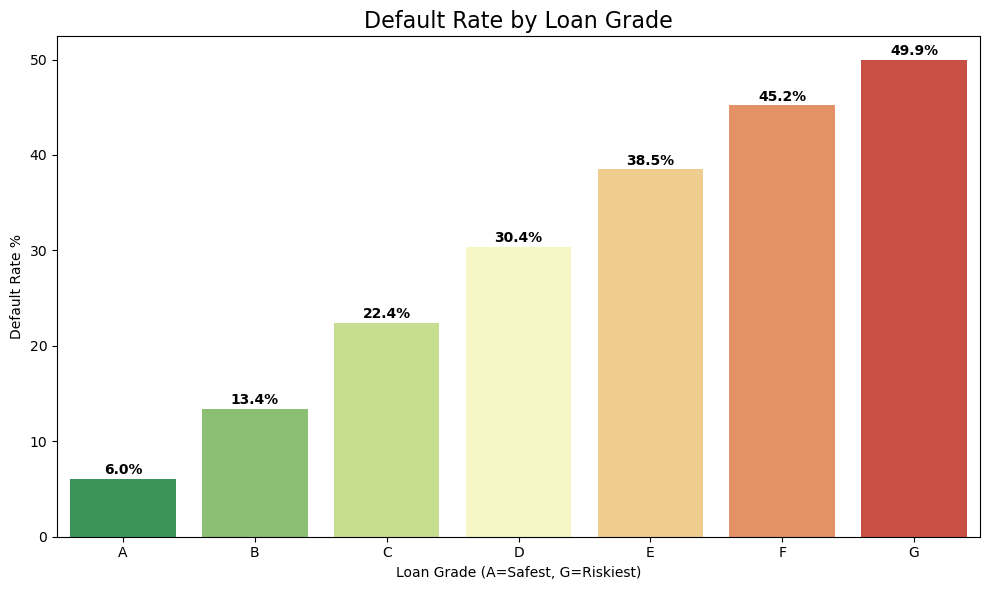

grade
A     6.040665
B    13.385157
C    22.439649
D    30.382229
E    38.478377
F    45.202446
G    49.934297
Name: default, dtype: float64


In [2]:
# ── CHART 1: DEFAULT RATE BY GRADE ───────────

grade_default = df.groupby('grade')['default'].mean() * 100
grade_default = grade_default.sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=grade_default.index, y=grade_default.values, palette='RdYlGn_r')
plt.title('Default Rate by Loan Grade', fontsize=16)
plt.xlabel('Loan Grade (A=Safest, G=Riskiest)')
plt.ylabel('Default Rate %')

for i, v in enumerate(grade_default.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/chart1_default_by_grade.png', dpi=150)
plt.show()

print(grade_default)

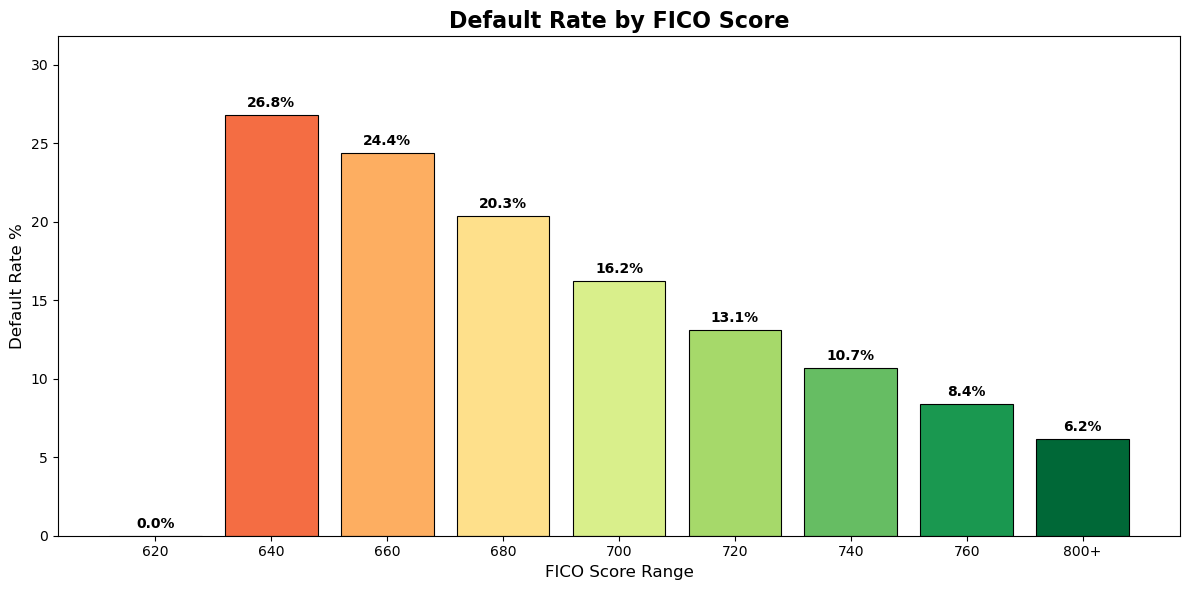

In [ ]:
# ── CHART 2 FIXED ─────────────────────────────
df['fico_bucket'] = pd.cut(df['fico_range_low'],
    bins=[600,620,640,660,680,700,720,740,760,800,850],
    labels=['<620','620','640','660','680','700','720','740','760','800+'])

fico_default = df.groupby('fico_bucket', observed=True)['default'].mean() * 100

plt.figure(figsize=(12,6))
colors = ['#d73027','#f46d43','#fdae61','#fee08b','#d9ef8b',
    '#a6d96a','#66bd63','#1a9850','#006837','#004529']

bars = plt.bar(fico_default.index, fico_default.values, color=colors, edgecolor='black', linewidth=0.8)

plt.title('Default Rate by FICO Score', fontsize=16, fontweight='bold')
plt.xlabel('FICO Score Range', fontsize=12)
plt.ylabel('Default Rate %', fontsize=12)

for bar, v in zip(bars, fico_default.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
         bar.get_height() + 0.5, 
             f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.ylim(0, fico_default.max() + 5)
plt.tight_layout()
plt.savefig('outputs/chart2_default_by_fico.png', dpi=150)
plt.show()

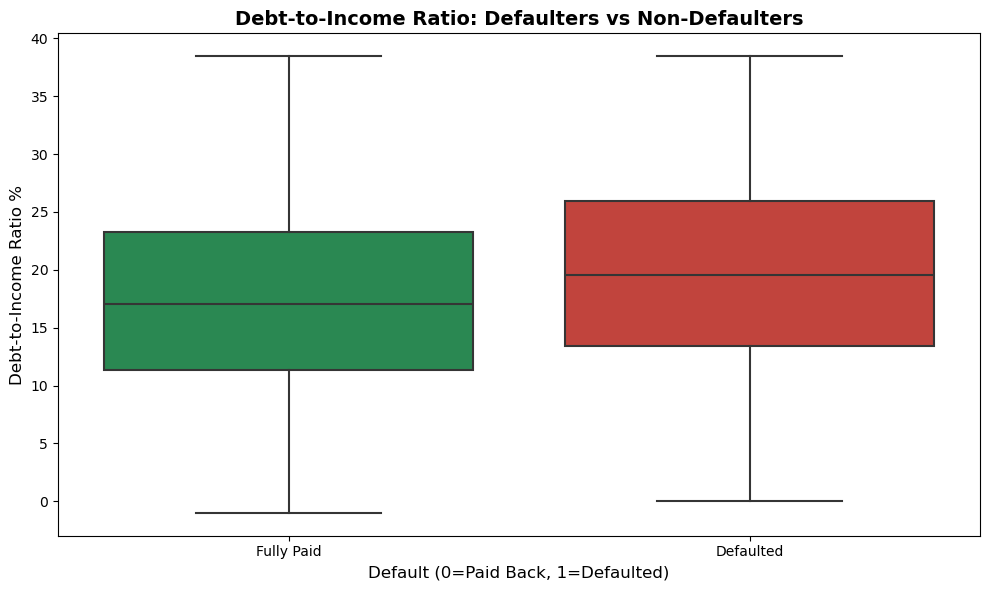

In [9]:
# Cap DTI at 99th percentile — remove extreme outliers
dti_cap = df['dti'].quantile(0.99)
df_plot = df[df['dti'] < dti_cap]

plt.figure(figsize=(10,6))
sns.boxplot(x='default', y='dti', data=df_plot,
            palette={0:'#1a9850', 1:'#d73027'})

plt.title('Debt-to-Income Ratio: Defaulters vs Non-Defaulters',
          fontsize=14, fontweight='bold')
plt.xticks([0,1], ['Fully Paid', 'Defaulted'])
plt.xlabel('Default (0=Paid Back, 1=Defaulted)', fontsize=12)
plt.ylabel('Debt-to-Income Ratio %', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/chart3_dti_vs_default.png', dpi=150)
plt.show()

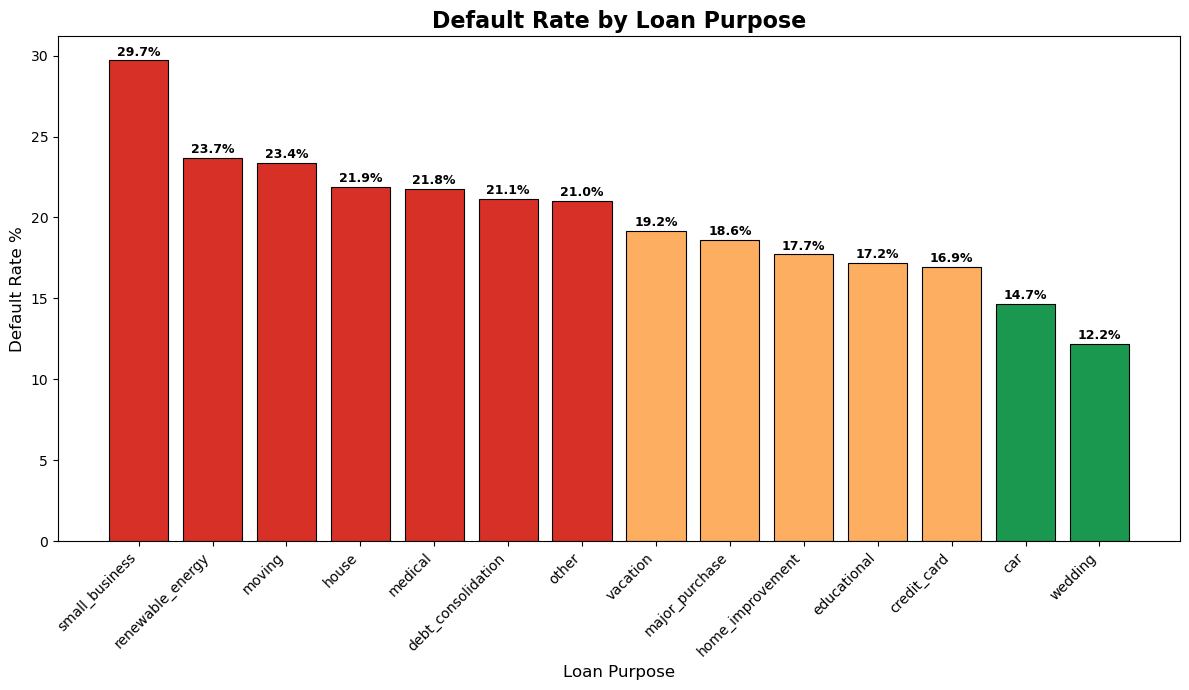

In [ ]:
# ── CHART 4: DEFAULT RATE BY PURPOSE ─────────
purpose_default = df.groupby('purpose')['default'].mean() * 100
purpose_default = purpose_default.sort_values(ascending=False)

plt.figure(figsize=(12,7))
colors = ['#d73027' if v > 20 else '#fdae61' if v > 15 else '#1a9850' 
    for v in purpose_default.values]

bars = plt.bar(purpose_default.index, purpose_default.values, 
     color=colors, edgecolor='black', linewidth=0.8)

plt.title('Default Rate by Loan Purpose', fontsize=16, fontweight='bold')
plt.xlabel('Loan Purpose', fontsize=12)
plt.ylabel('Default Rate %', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar, v in zip(bars, purpose_default.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/chart4_default_by_purpose.png', dpi=150)
plt.show()

In [ ]:
# ── CHART 5: CORRELATION HEATMAP ─────────────
# Shows how all numeric features relate to each other
# and to our target variable (default)

numeric_cols = ['loan_amnt','int_rate','installment','annual_inc',
    'dti','fico_range_low','open_acc','pub_rec',
    'revol_bal','revol_util','total_acc','default']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, annot_kws={'size':9})

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/chart5_correlation_heatmap.png', dpi=150)
plt.show()

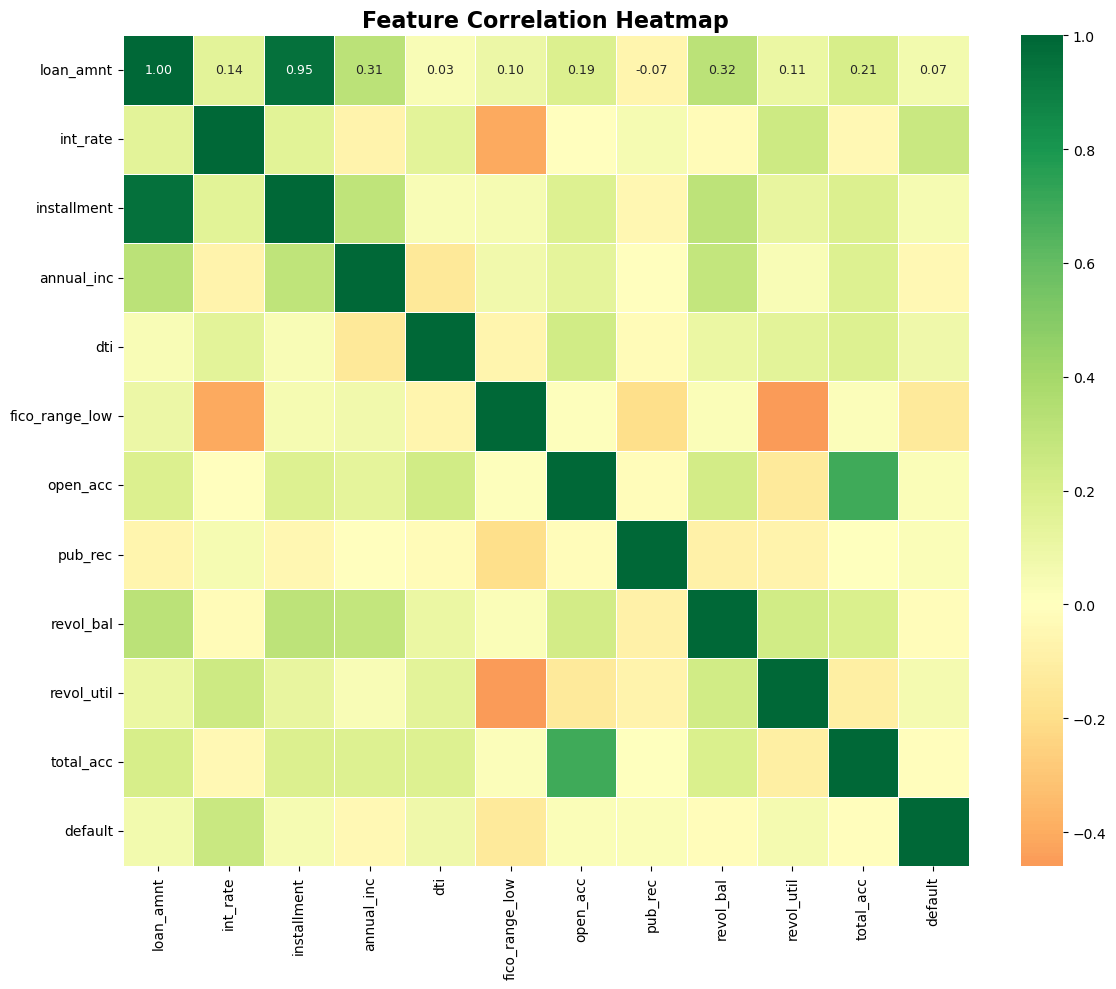

In [10]:
# ── CHART 5: CORRELATION HEATMAP ─────────────
# Shows how all numeric features relate to each other
# and to our target variable (default)

numeric_cols = ['loan_amnt','int_rate','installment','annual_inc',
    'dti','fico_range_low','open_acc','pub_rec',
    'revol_bal','revol_util','total_acc','default']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, annot_kws={'size':9})

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/chart5_correlation_heatmap.png', dpi=150)
plt.show()

In [11]:
# Save cleaned data with fico_bucket dropped
df = df.drop(columns=['fico_bucket'])
df.to_csv("outputs/02_cleaned_data.csv", index=False)
print("✓ Updated cleaned data saved")

✓ Updated cleaned data saved
